Total parameter combinations: 432
Total iterations (parameter combinations × CV folds): 4320
Starting Grid Search...
Grid Search Progress |▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉| 4320/4320 [100%]Grid Search Progress |▉▉▉▉▊                                   | ▄▆█ 532/4320 [12Grid Search Progress |▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉                        | ▄▆█ 1722/4320 [4Grid Search Progress |▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉           | ▇▇▅ 3135/4320 [7Grid Search Progress |▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▏          | █▆▄ 3140/4320 [7Grid Search Progress |▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▏   | ▇▇▅ 3905/4320 [9
Grid Search Completed.

Best Average AUC: 0.7590 ± 0.0283
Average Accuracy: 0.8796 ± 0.0147
Average Precision: 0.3179 ± 0.0816
Average F1 Score: 0.2908 ± 0.0708

Best Hyperparameters:
  gbc__learning_rate: 0.01
  gbc__loss: exponential
  gbc__max_depth: 20
  gbc__max_features: log2
  gbc__min_samples_leaf: 2
  gbc__min_samples_split: 5
  gbc__n_estimators: 125
  gbc__subsample: 0.1
  resampler: Rand

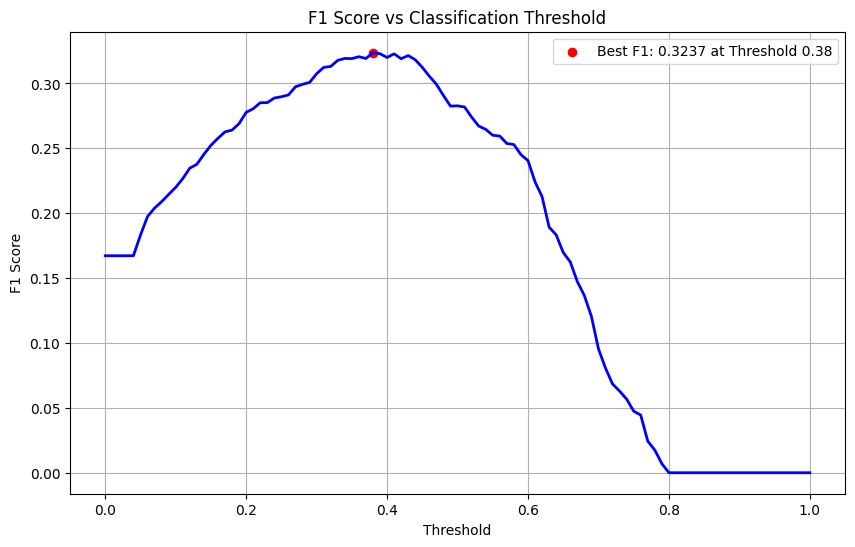

In [1]:
import warnings
from sklearn.exceptions import UndefinedMetricWarning, ConvergenceWarning
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, f1_score, make_scorer
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler
import matplotlib.pyplot as plt
from math import prod

# Import libraries for progress bar
from alive_progress import alive_bar
from contextlib import contextmanager
from joblib.parallel import BatchCompletionCallBack
import threading
import logging
import os

# Set environment variable to suppress Python warnings
os.environ['PYTHONWARNINGS'] = "ignore"

# Suppress logging warnings by setting the logging level to ERROR
logging.getLogger().setLevel(logging.ERROR)

# Suppress specific warnings globally
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore")  # Suppress all other warnings

# Define a context manager to integrate alive-progress with joblib's Parallel processing
@contextmanager
def alive_joblib_bar(total):
    """
    Context manager to integrate alive-progress with joblib's Parallel processing.

    Parameters:
    - total: int, the total number of tasks to be processed.
    """
    with alive_bar(total, title='Grid Search Progress', bar='blocks', force_tty=True) as bar:
        # Store the original BatchCompletionCallBack.__call__ method
        original_callback = BatchCompletionCallBack.__call__
        lock = threading.Lock()

        def on_complete(self, *args, **kwargs):
            with lock:
                bar()
            return original_callback(self, *args, **kwargs)

        # Patch the BatchCompletionCallBack.__call__ method
        BatchCompletionCallBack.__call__ = on_complete
        try:
            yield
        finally:
            # Restore the original method to avoid side effects
            BatchCompletionCallBack.__call__ = original_callback

# Load the dataset
# Replace the file path with your actual path
data = pd.read_excel("class123_dataset.xlsx")

# Extract the predictors and outcome
X = data.drop('RRI', axis=1)
Y = data['RRI']

# Define the feature indexes to be used as predictors
# Note: Pandas uses 0-based indexing
feature_indexes = [138, 244, 224, 137, 118, 103, 230, 204, 42, 13, 86, 3]

# Select the specified features using .iloc
X_selected = X.iloc[:, feature_indexes]

# Initialize the Gradient Boosting Classifier
gbc = GradientBoostingClassifier(random_state=42)

# Initialize the resampling strategies
resamplers = [
    ('smote', SMOTE()),
    ('adasyn', ADASYN()),
    ('random_oversampler', RandomOverSampler())
]

# Create a Pipeline with Resampler and Gradient Boosting
pipeline = ImbPipeline([
    ('resampler', SMOTE()),  # Placeholder, will be set in GridSearchCV
    ('gbc', gbc)
])

# Define the parameter grid for hyperparameter tuning
param_grid = {
    # Resampling strategies
    'resampler': [RandomOverSampler()],
    
    # Sampling strategies (only relevant if resampler is not 'passthrough')
    'resampler__sampling_strategy': [0.3, 0.5],
    
    # Gradient Boosting parameters
    'gbc__n_estimators': [125, 150, 175],
    'gbc__learning_rate': [0.01],
    'gbc__max_depth': [6, 10, 20],
    'gbc__min_samples_split': [5],
    'gbc__min_samples_leaf': [2],
    'gbc__max_features': ['auto', 'sqrt', 'log2', None],
    'gbc__subsample': [0.1, 0.2, 0.3],
    'gbc__loss': ['deviance', 'exponential']
}

# Define the scoring metrics
scoring = {
    'roc_auc': 'roc_auc',
    'accuracy': 'accuracy',
    'precision': make_scorer(precision_score, zero_division=0),
    'f1': make_scorer(f1_score, zero_division=0)
}

# Define the Stratified 10-Fold Cross-Validation
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Calculate the total number of parameter combinations
n_param_combinations = prod([len(v) for v in param_grid.values()])

# Calculate the total number of iterations (parameter combinations × CV folds)
total_iterations = n_param_combinations * cv.get_n_splits(X_selected, Y)

print(f"Total parameter combinations: {n_param_combinations}")
print(f"Total iterations (parameter combinations × CV folds): {total_iterations}")

# Initialize Grid Search with cross-validation
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring=scoring,
    refit='roc_auc',  # Use 'roc_auc' to select the best model
    cv=cv,
    n_jobs=64,  # Use all available cores
    verbose=0,  # Disable sklearn's verbose
    return_train_score=False
)

# Start the Grid Search with alive-progress
print("Starting Grid Search...")

with alive_joblib_bar(total_iterations):
    grid_search.fit(X_selected, Y)

print("Grid Search Completed.")

# Retrieve the best average AUC and its standard deviation
best_auc = grid_search.best_score_
# Retrieve the standard deviation from cv_results_
# Identify the index of the best parameter set
best_index = grid_search.best_index_
best_auc_std = grid_search.cv_results_['std_test_roc_auc'][best_index]

# Retrieve the best hyperparameters
best_params = grid_search.best_params_

# Retrieve the other metrics for the best parameter set
best_accuracy = grid_search.cv_results_['mean_test_accuracy'][best_index]
best_accuracy_std = grid_search.cv_results_['std_test_accuracy'][best_index]

best_precision = grid_search.cv_results_['mean_test_precision'][best_index]
best_precision_std = grid_search.cv_results_['std_test_precision'][best_index]

best_f1 = grid_search.cv_results_['mean_test_f1'][best_index]
best_f1_std = grid_search.cv_results_['std_test_f1'][best_index]

# Output the results
print(f"\nBest Average AUC: {best_auc:.4f} ± {best_auc_std:.4f}")
print(f"Average Accuracy: {best_accuracy:.4f} ± {best_accuracy_std:.4f}")
print(f"Average Precision: {best_precision:.4f} ± {best_precision_std:.4f}")
print(f"Average F1 Score: {best_f1:.4f} ± {best_f1_std:.4f}")
print("\nBest Hyperparameters:")
for param, value in best_params.items():
    if isinstance(value, (SMOTE, ADASYN, RandomOverSampler)):
        print(f"  {param}: {value.__class__.__name__}")
    else:
        print(f"  {param}: {value}")

# Retrieve the best estimator from Grid Search
best_estimator = grid_search.best_estimator_

# Use cross_val_predict to get cross-validated predicted probabilities
# GradientBoostingClassifier inherently supports predict_proba
print("\nGenerating cross-validated predicted probabilities...")
y_pred_proba = cross_val_predict(best_estimator, X_selected, Y, cv=cv, method='predict_proba', n_jobs=64)[:, 1]

# Define a range of threshold values to evaluate
thresholds = np.linspace(0.0, 1.0, 101)

# Initialize variables to store the best metrics and threshold
best_threshold = 0.5
best_f1_score = 0.0
best_accuracy = 0.0
best_precision = 0.0

print("Optimizing threshold to maximize F1 score...")

for threshold in thresholds:
    # Convert predicted probabilities to binary predictions based on the threshold
    y_pred = (y_pred_proba >= threshold).astype(int)

    # Calculate F1 score
    current_f1 = f1_score(Y, y_pred, zero_division=0)

    # Update the best metrics and threshold if current F1 is better
    if current_f1 > best_f1_score:
        best_f1_score = current_f1
        best_threshold = threshold
        best_accuracy = accuracy_score(Y, y_pred)
        best_precision = precision_score(Y, y_pred, zero_division=0)

# Calculate standard deviations using cross-validation
# To compute standard deviations, we'll perform cross-validation predictions and calculate metrics at the best threshold

# Initialize lists to store per-fold metrics
f1_scores = []
accuracies = []
precisions = []

print("\nCalculating metrics at the optimal threshold across folds...")

for fold, (train_idx, test_idx) in enumerate(cv.split(X_selected, Y), 1):
    # Split data
    X_train, X_test = X_selected.iloc[train_idx], X_selected.iloc[test_idx]
    y_train, y_test = Y.iloc[train_idx], Y.iloc[test_idx]

    # Fit the model on the training data
    best_estimator.fit(X_train, y_train)

    # Predict probabilities on the test data
    y_proba_fold = best_estimator.predict_proba(X_test)[:, 1]

    # Apply the optimal threshold
    y_pred_fold = (y_proba_fold >= best_threshold).astype(int)

    # Calculate metrics
    fold_f1 = f1_score(y_test, y_pred_fold, zero_division=0)
    fold_accuracy = accuracy_score(y_test, y_pred_fold)
    fold_precision = precision_score(y_test, y_pred_fold, zero_division=0)

    # Append to lists
    f1_scores.append(fold_f1)
    accuracies.append(fold_accuracy)
    precisions.append(fold_precision)

    print(f"  Fold {fold}: F1={fold_f1:.4f}, Accuracy={fold_accuracy:.4f}, Precision={fold_precision:.4f}")

# Calculate mean and standard deviation for the metrics
mean_f1 = np.mean(f1_scores)
std_f1 = np.std(f1_scores)

mean_accuracy = np.mean(accuracies)
std_accuracy = np.std(accuracies)

mean_precision = np.mean(precisions)
std_precision = np.std(precisions)

# Output the optimized threshold and corresponding metrics
print(f"\n=== Optimized Threshold ===")
print(f"Threshold for Maximum F1 Score: {best_threshold:.2f}")

print(f"\n=== Metrics at Optimal Threshold ===")
print(f"F1 Score: {mean_f1:.4f} ± {std_f1:.4f}")
print(f"Accuracy: {mean_accuracy:.4f} ± {std_accuracy:.4f}")
print(f"Precision: {mean_precision:.4f} ± {std_precision:.4f}")

# Plot F1 Score vs Threshold
f1_scores_plot = []
for threshold in thresholds:
    y_pred = (y_pred_proba >= threshold).astype(int)
    f1 = f1_score(Y, y_pred, zero_division=0)
    f1_scores_plot.append(f1)

plt.figure(figsize=(10, 6))
plt.plot(thresholds, f1_scores_plot, color='blue', lw=2)
plt.scatter(best_threshold, best_f1_score, color='red', 
            label=f'Best F1: {best_f1_score:.4f} at Threshold {best_threshold:.2f}')
plt.title('F1 Score vs Classification Threshold')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.legend()
plt.grid(True)
plt.show()

In [2]:
print(f"\n=== Optimized Threshold ===")
print(f"Threshold for Maximum F1 Score: {best_threshold:.2f}")

print(f"\n=== Metrics at Optimal Threshold ===")
print(f"F1 Score: {mean_f1:.4f} ± {std_f1:.4f}")
print(f"Accuracy: {mean_accuracy:.4f} ± {std_accuracy:.4f}")
print(f"Precision: {mean_precision:.4f} ± {std_precision:.4f}")


=== Optimized Threshold ===
Threshold for Maximum F1 Score: 0.38

=== Metrics at Optimal Threshold ===
F1 Score: 0.3158 ± 0.0523
Accuracy: 0.8317 ± 0.0175
Precision: 0.2520 ± 0.0440
